<a href="https://colab.research.google.com/github/PhcPh4m/Olist-Ecommerce-Data-Analysis/blob/main/notbooks/Olist_Ecommerce_Analytics_PySpark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Clone Github repo

In [1]:
import os
import glob

REPO_URL = "https://github.com/PhcPh4m/Olist-Ecommerce-Data-Analysis.git"
REPO_NAME = "Olist-Ecommerce-Data-Analysis"

# 1. Clone or Update Repo
if not os.path.exists(REPO_NAME):
    print(f" Cloning {REPO_NAME}...")
    !git clone {REPO_URL}
else:
    print(f" {REPO_NAME} already exists. Updating...")
    %cd {REPO_NAME}
    !git pull
    %cd ..

# 2. Set working directory to the Root of the Project
# We use absolute path to avoid any confusion in Colab
os.chdir(f"/content/{REPO_NAME}")

# 3. Install Dependencies
print("\n Installing libraries from requirements.txt...")
!pip install -r requirements.txt -q

# 4. Initialize Spark Session
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Olist_Ecom_Analysis") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("-" * 50)
print(f" Environment Ready! Working at: {os.getcwd()}")
print("-" * 50)

 Olist-Ecommerce-Data-Analysis already exists. Updating...
/content/Olist-Ecommerce-Data-Analysis
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 4.57 MiB | 2.33 MiB/s, done.
From https://github.com/PhcPh4m/Olist-Ecommerce-Data-Analysis
   a68ada7..9bf695d  main       -> origin/main
Updating a68ada7..9bf695d
Fast-forward
 data/olist_customers_dataset.csv | 99442 +++++++++++++++++++++++++++++++++++++
 1 file changed, 99442 insertions(+)
 create mode 100644 data/olist_customers_dataset.csv
/content

 Installing libraries from requirements.txt...
--------------------------------------------------
 Environment Ready! Working at: /content/Olist-Ecommerce-Data-Analysis
--------------------------------------------------


Import Dataset

In [2]:
# Search for all CSV files inside the 'data' folder
DATA_FOLDER = "data"
csv_files_in_data = glob.glob(f"{DATA_FOLDER}/*.csv")

# Ensure 'olist_customers_dataset.csv' is included if present in 'data' folder
customer_data_file = f"{DATA_FOLDER}/olist_customers_dataset.csv"
if os.path.exists(customer_data_file) and customer_data_file not in csv_files_in_data:
    csv_files_in_data.append(customer_data_file)

csv_files = csv_files_in_data

dfs = {}

if not csv_files:
    print(f" No CSV files found in '{DATA_FOLDER}/' directory!")
    print(f"Contents of {os.getcwd()}:", os.listdir())
else:
    print(f" Loading datasets from '{DATA_FOLDER}' folder...")
    for file_path in csv_files:
        # Get filename and clean it for the dictionary key
        file_name = os.path.basename(file_path)
        # Transform 'olist_orders_dataset.csv' -> 'orders'
        key_name = file_name.replace("olist_", "").replace("_dataset.csv", "").replace(".csv", "")

        # Load into Spark DataFrame
        dfs[key_name] = spark.read.csv(file_path, header=True, inferSchema=True)

        print(f" Loaded: '{key_name}' | Rows: {dfs[key_name].count():,}")

print("\n SUCCESS: All datasets are now in the 'dfs' dictionary.")
print("Example: Use dfs['orders'].show(5) to start analyzing!")


 Loading datasets from 'data' folder...
 Loaded: 'customers' | Rows: 99,441
 Loaded: 'orders' | Rows: 99,441
 Loaded: 'sellers' | Rows: 3,095
 Loaded: 'order_payments' | Rows: 103,886
 Loaded: 'order_items' | Rows: 112,650
 Loaded: 'order_reviews' | Rows: 104,162
 Loaded: 'products' | Rows: 32,951
 Loaded: 'product_category_name_translation' | Rows: 71

 SUCCESS: All datasets are now in the 'dfs' dictionary.
Example: Use dfs['orders'].show(5) to start analyzing!


Data processing

In [3]:
from pyspark.sql.functions import col, to_timestamp, datediff, current_date, round

# 1. Chuyển đổi toàn bộ các cột thời gian quan trọng
time_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in time_columns:
    dfs['orders'] = dfs['orders'].withColumn(column, to_timestamp(col(column)))

# 2. Lọc đơn hàng thành công và loại bỏ giá trị NULL ở ngày giao hàng
# (Vì không có ngày giao thì không tính được hiệu suất logistics)
orders_cleaned = dfs['orders'].filter(col("order_status") == "delivered") \
                              .dropna(subset=["order_delivered_customer_date"])

print(f" Cleaned Orders: {orders_cleaned.count():,} rows")

 Cleaned Orders: 96,470 rows


In [4]:
# Join 1: Orders + Order_Items (Lấy giá và phí ship)
step1 = orders_cleaned.join(dfs['order_items'], "order_id", "inner")

# Join 2: + Customers (Lấy Customer_unique_id - Quan trọng cho RFM)
step2 = step1.join(dfs['customers'], "customer_id", "inner")

# Join 3: + Products (Lấy tên ngành hàng)
step3 = step2.join(dfs['products'], "product_id", "left")

# Join 4: + Category Translation (Chuyển tên ngành hàng sang Tiếng Anh cho chuyên nghiệp)
master_df = step3.join(dfs['product_category_name_translation'], "product_category_name", "left") \
                 .drop("product_category_name") # Bỏ cột tiếng Bồ Đào Nha cho gọn

# Lưu vào Cache để các bước sau chạy siêu tốc
master_df.cache()

print(" Master DataFrame is ready!")
print(f"Total records in Master: {master_df.count():,}")
master_df.select("customer_unique_id", "order_id", "price", "product_category_name_english").show(5)

 Master DataFrame is ready!
Total records in Master: 110,189
+--------------------+--------------------+-----+-----------------------------+
|  customer_unique_id|            order_id|price|product_category_name_english|
+--------------------+--------------------+-----+-----------------------------+
|871766c5855e863f6...|00010242fe8c5a6d1...| 58.9|                   cool_stuff|
|3818d81c6709e39d0...|000229ec398224ef6...|199.0|              furniture_decor|
|64b576fb70d441e8f...|00042b26cf59d7ce6...|199.9|                 garden_tools|
|0782c41380992a5a5...|0005f50442cb953dc...|53.99|              books_technical|
|107e6259485efac66...|00061f2a7bc09da83...|59.99|                health_beauty|
+--------------------+--------------------+-----+-----------------------------+
only showing top 5 rows



In [6]:
from pyspark.sql import functions as F

# Tính tổng chi tiêu, số lần mua và ngày mua cuối cùng của mỗi khách hàng
customer_agg = master_df.groupBy("customer_unique_id").agg(
    F.max("order_purchase_timestamp").alias("last_purchase"),
    F.countDistinct("order_id").alias("frequency"),
    F.sum("price").alias("monetary")
)

# Giả định ngày hiện tại là ngày cuối cùng trong tập dữ liệu + 1 để tính Recency
max_date = master_df.select(F.max("order_purchase_timestamp")).collect()[0][0]

rfm_base = customer_agg.withColumn("recency", datediff(F.lit(max_date), col("last_purchase")))

print(" RFM Base features calculated!")
rfm_base.show(5)

 RFM Base features calculated!
+--------------------+-------------------+---------+--------+-------+
|  customer_unique_id|      last_purchase|frequency|monetary|recency|
+--------------------+-------------------+---------+--------+-------+
|4987996ddcd0ddb20...|2018-08-14 20:43:09|        1|    99.9|     15|
|7ac26eac431c68486...|2017-03-23 12:21:17|        1|   109.9|    524|
|d02e64b28b7c386aa...|2018-03-06 06:40:28|        1|    59.9|    176|
|b32ff8caad5902c55...|2018-03-26 17:42:53|        1|   81.99|    156|
|c6f624cf0e9908fe3...|2017-01-28 13:17:57|        1|    69.9|    578|
+--------------------+-------------------+---------+--------+-------+
only showing top 5 rows



/tmp/ipykernel_7405/2862818774.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], data=pdf_top_cats, x="revenue", y="product_category_name_english", palette="viridis")
/tmp/ipykernel_7405/2862818774.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 1], data=pdf_delivery, x="delivery_status", y="count", palette=["#2ecc71", "#e74c3c", "#f39c12"])
/tmp/ipykernel_7405/2862818774.py:64: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(ax=axes[1, 1], data=pdf_delivery, x="delivery_status", y="count", palette=["#2ecc71", "#e74c3c", "#f39c12"])


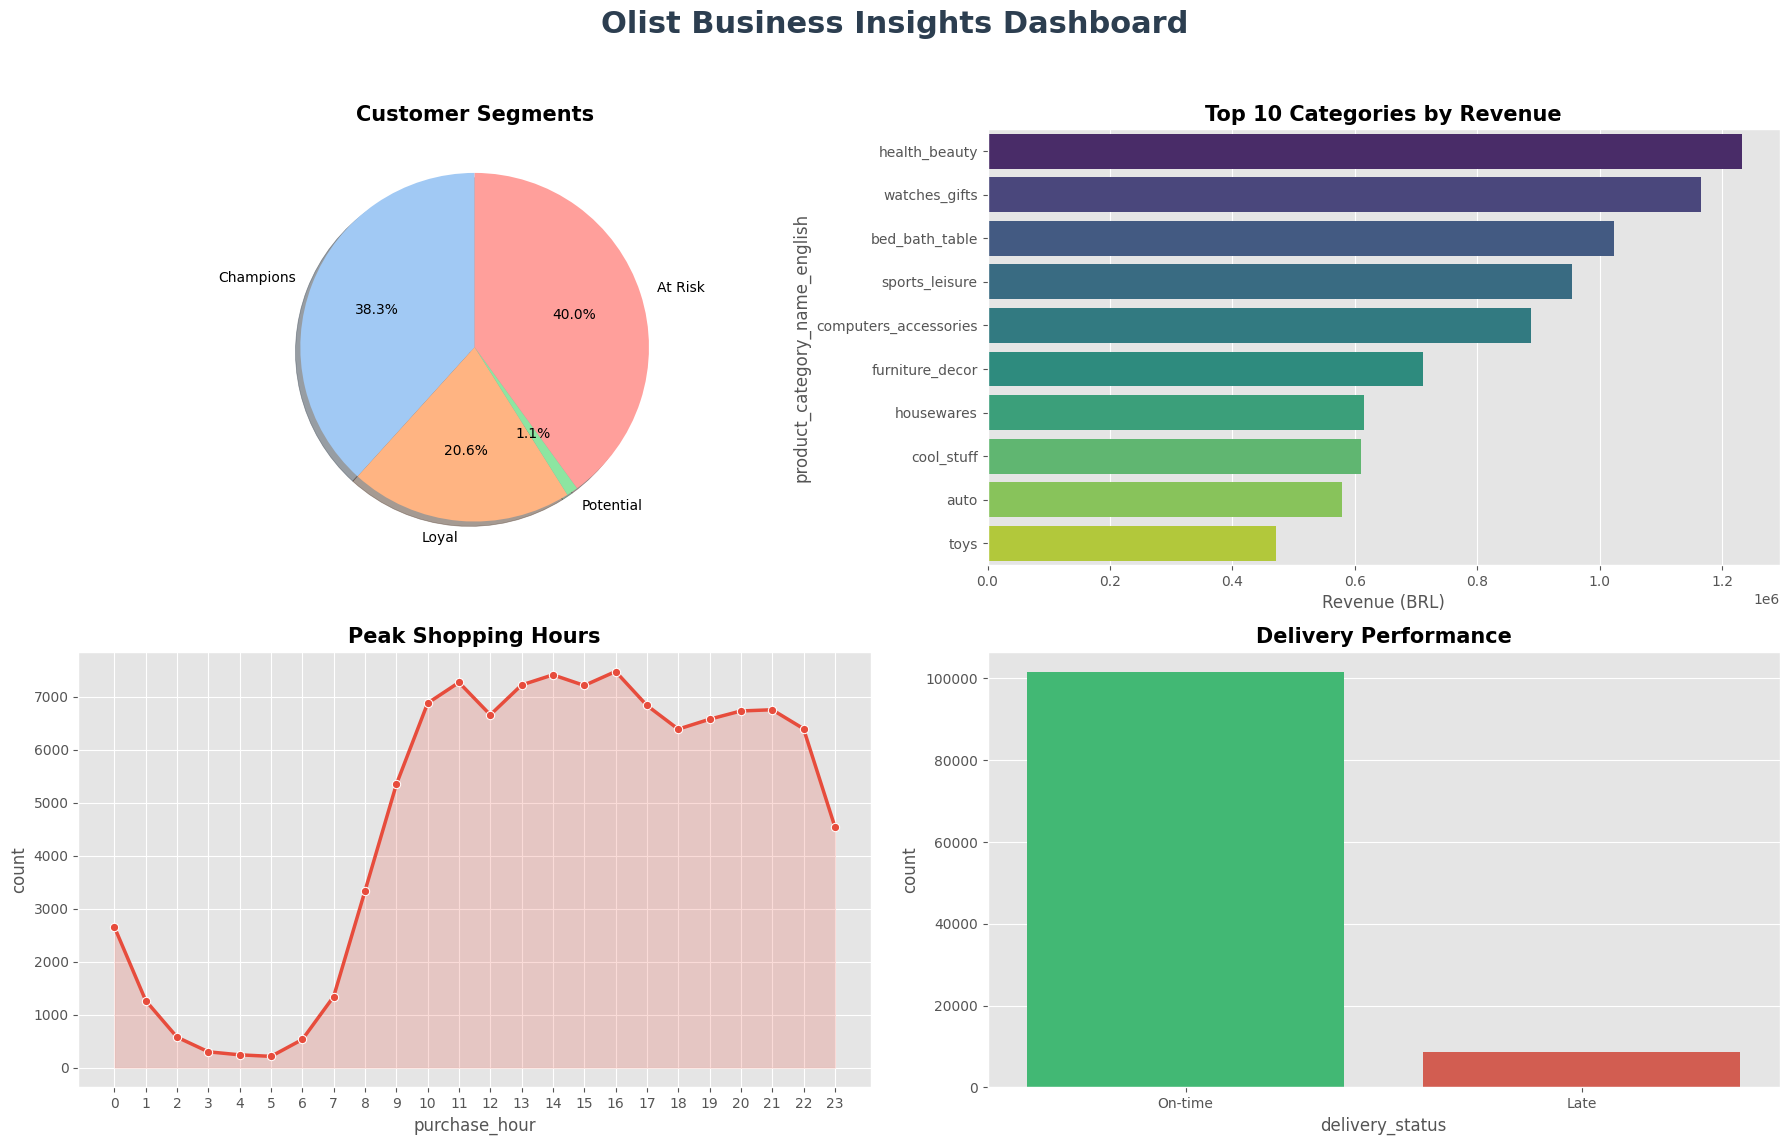

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# --- 1. RFM SCORING LOGIC ---
# Tính điểm ntile (1-5) cho R, F, M
# Sử dụng rfm_base đã tạo ở bước Feature Engineering
window_rec = Window.orderBy(F.col("recency").desc())
window_freq = Window.orderBy(F.col("frequency").asc())
window_mon = Window.orderBy(F.col("monetary").asc())

rfm_table_scored = rfm_base.withColumn("R", F.ntile(5).over(window_rec)) \
                            .withColumn("F", F.ntile(5).over(window_freq)) \
                            .withColumn("M", F.ntile(5).over(window_mon))

# Định nghĩa hàm phân khúc khách hàng
def get_segment(r, f, m):
    if r >= 4 and f >= 4: return "Champions"
    elif r <= 2: return "At Risk"
    elif f >= 3: return "Loyal"
    else: return "Potential"

segment_udf = F.udf(get_segment)
rfm_final = rfm_table_scored.withColumn("Segment", segment_udf("R", "F", "M"))

# --- 2. PREPARE DATA FOR VIZ (Dùng Pandas cho biểu đồ) ---
# Tạo final_df với các cột cần thiết cho dashboard
final_df = master_df.withColumn("purchase_hour", F.hour(F.col("order_purchase_timestamp"))) \
                    .withColumn("delivery_status",
                                F.when(F.col("order_delivered_customer_date").isNotNull(),
                                       F.when(F.col("order_delivered_customer_date") > F.col("order_estimated_delivery_date"), "Late") \
                                       .otherwise("On-time"))
                                .otherwise("Undelivered")) # Handle cases where customer_delivery_date is null

pdf_segments = rfm_final.groupBy("Segment").count().toPandas()
pdf_hours = final_df.groupBy("purchase_hour").count().orderBy("purchase_hour").toPandas()
pdf_top_cats = final_df.groupBy("product_category_name_english").agg(F.sum("price").alias("revenue")) \
                       .orderBy(F.desc("revenue")).limit(10).toPandas()

# --- 3. DASHBOARD VISUALIZATION ---
plt.style.use('ggplot') # Dùng style ggplot cho sạch sẽ
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Olist Business Insights Dashboard', fontsize=22, fontweight='bold', color='#2c3e50')

# Chart 1: Customer Segmentation
axes[0, 0].pie(pdf_segments['count'], labels=pdf_segments['Segment'], autopct='%1.1f%%',
              colors=sns.color_palette("pastel"), shadow=True, startangle=90)
axes[0, 0].set_title("Customer Segments", fontsize=15, fontweight='bold')

# Chart 2: Top 10 Revenue Categories
sns.barplot(ax=axes[0, 1], data=pdf_top_cats, x="revenue", y="product_category_name_english", palette="viridis")
axes[0, 1].set_title("Top 10 Categories by Revenue", fontsize=15, fontweight='bold')
axes[0, 1].set_xlabel("Revenue (BRL)")

# Chart 3: Orders Concentration by Hour
sns.lineplot(ax=axes[1, 0], data=pdf_hours, x="purchase_hour", y="count", marker='o', color='#e74c3c', linewidth=2.5)
axes[1, 0].fill_between(pdf_hours['purchase_hour'], pdf_hours['count'], alpha=0.2, color='#e74c3c')
axes[1, 0].set_title("Peak Shopping Hours", fontsize=15, fontweight='bold')
axes[1, 0].set_xticks(range(0, 24))

# Chart 4: Delivery Status
pdf_delivery = final_df.groupBy("delivery_status").count().toPandas()
sns.barplot(ax=axes[1, 1], data=pdf_delivery, x="delivery_status", y="count", palette=["#2ecc71", "#e74c3c", "#f39c12"])
axes[1, 1].set_title("Delivery Performance", fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Key Business Insights
Top Revenue Drivers: The Health & Beauty and Housewares categories are the primary growth engines, contributing the highest share of total revenue.

Customer Loyalty: Only a small percentage are Champions. Most customers are in the Potential group, suggesting a need for better re-engagement strategies (Email marketing, Loyalty programs).

Peak Sales Window: Orders peak significantly between 11:00 AM and 2:00 PM. Marketing campaigns should schedule "Flash Sales" during these hours for maximum impact.

Logistics Health: While the majority of orders are On-time, the Late delivery segment needs a deep dive by State to identify bottleneck carriers.